# =========================================================
# IMPORTS
# =========================================================

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# =========================================================
# LOAD DATA PREPROCESSED (.npy)
# =========================================================

In [3]:
X_train = np.load("../data/X_train.npy")
X_val   = np.load("../data/X_val.npy")
X_test  = np.load("../data/X_test.npy")

y_train = np.load("../data/y_train.npy")
y_val   = np.load("../data/y_val.npy")
y_test  = np.load("../data/y_test.npy")

print("Train :", X_train.shape)
print("Val   :", X_val.shape)
print("Test  :", X_test.shape)

Train : (237280, 27)
Val   : (50846, 27)
Test  : (50846, 27)


# =========================================================
# MODEL ARCHITECTURE (MLP)
# =========================================================

In [4]:
model = Sequential([

    # Input layer + first hidden layer
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.3),

    # Second hidden layer
    Dense(64, activation="relu"),
    Dropout(0.3),

    # Third hidden layer (améliore la capacité)
    Dense(32, activation="relu"),
    Dropout(0.2),

    # Output layer (régression)
    Dense(1)

])

c:\Users\ALPHA\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# =========================================================
# COMPILATION
# =========================================================

In [5]:
model.compile(

    optimizer="adam",

    loss="mse",

    metrics=["mae"]

)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,953 (54.50 KB)

 Trainable params: 13,953 (54.50 KB)

 Non-trainable params: 0 (0.00 B)

# =========================================================
# CALLBACKS (STABILITY + PERFORMANCE)
# =========================================================

In [6]:
early_stop = EarlyStopping(

    monitor="val_loss",

    patience=5,

    restore_best_weights=True

)

lr_scheduler = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=3,

    verbose=1

)

# =========================================================
# TRAINING MODEL
# =========================================================


In [7]:
history = model.fit(

    X_train,
    y_train,

    validation_data=(X_val, y_val),

    epochs=50,

    batch_size=32,

    callbacks=[early_stop, lr_scheduler],

    verbose=1

)

Epoch 1/50
7415/7415 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - loss: 78.6967 - mae: 5.9227 - val_loss: 55.5440 - val_mae: 5.0557 - learning_rate: 0.0010
Epoch 2/50
7415/7415 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - loss: 62.7058 - mae: 5.3639 - val_loss: 51.9295 - val_mae: 4.9204 - learning_rate: 0.0010
Epoch 3/50
7415/7415 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - loss: 59.9751 - mae: 5.2598 - val_loss: 51.6865 - val_mae: 4.8834 - learning_rate: 0.0010
Epoch 4/50
7415/7415 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - loss: 58.5280 - mae: 5.1903 - val_loss: 52.6574 - val_mae: 4.9541 - learning_rate: 0.0010
Epoch 5/50
7415/7415 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 57.3603 - mae: 5.1344 - val_loss: 50.9675 - val_mae: 4.9436 - learning_rate: 0.0010
Epoch 6/50
7415/7415 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 56.8944 - mae: 5.0975 - val_loss: 50.3043 - val_mae: 4.8644 - learning_rate: 0.0010
Epoch 7/50
7415/7415 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - loss: 56.0598 - mae: 5.0717 - val_loss: 50.4432 - val_mae: 4.

# =========================================================
# PREDICTIONS
# =========================================================

In [8]:
y_pred = model.predict(X_test)

1589/1589 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


# =========================================================
# EVALUATION METRICS
# =========================================================

In [9]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n========================")
print("RESULTATS MLP")
print("========================")

print(f"MAE  : {mae:.2f} minutes")
print(f"RMSE : {rmse:.2f} minutes")


RESULTATS MLP
MAE  : 4.78 minutes
RMSE : 6.97 minutes


# =========================================================
# LOSS CURVE
# =========================================================

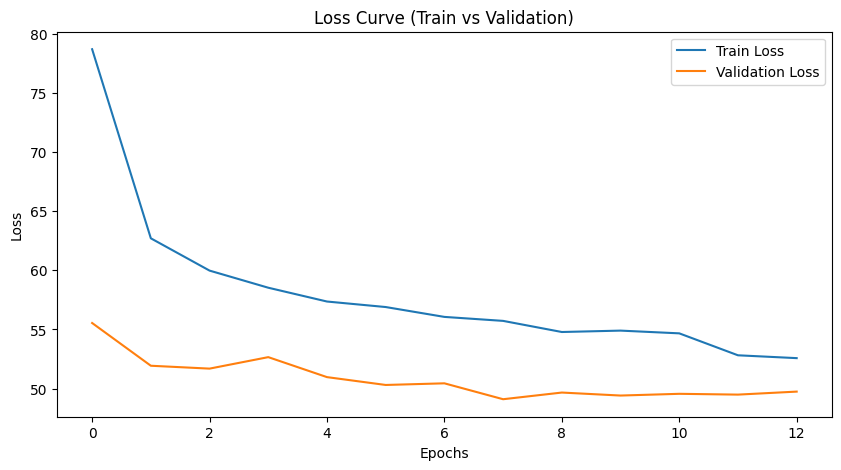

In [10]:
plt.figure(figsize=(10,5))

plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Loss Curve (Train vs Validation)")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()
plt.show()

# =========================================================
# MAE CURVE
# =========================================================

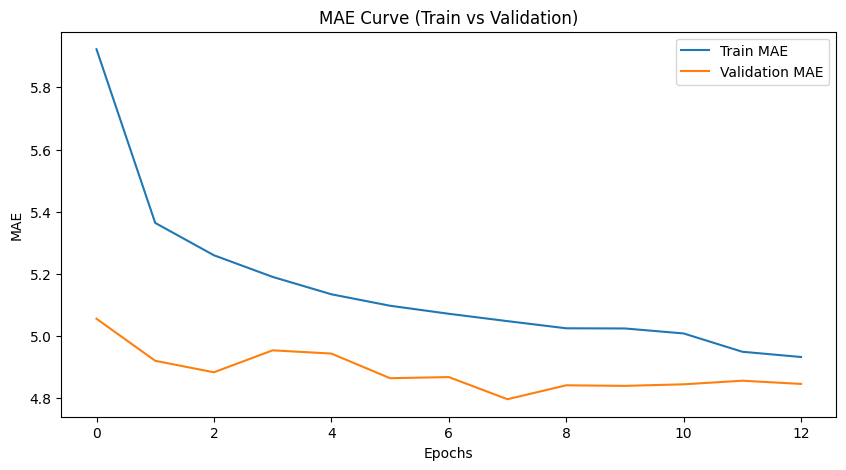

In [11]:
plt.figure(figsize=(10,5))

plt.plot(history.history["mae"], label="Train MAE")
plt.plot(history.history["val_mae"], label="Validation MAE")

plt.title("MAE Curve (Train vs Validation)")
plt.xlabel("Epochs")
plt.ylabel("MAE")

plt.legend()
plt.show()

# =========================================================
# RESIDUALS ANALYSIS
# =========================================================

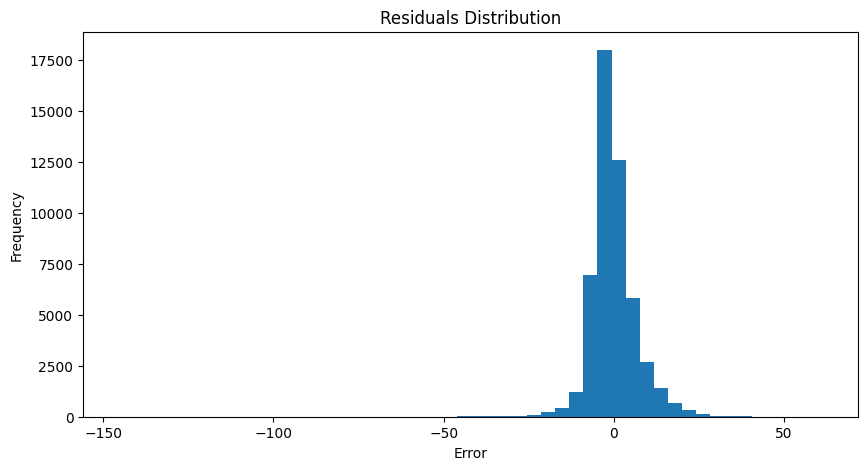

In [12]:
residuals = y_test - y_pred.flatten()

plt.figure(figsize=(10,5))

plt.hist(residuals, bins=50)

plt.title("Residuals Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")

plt.show()

# =========================================================
# SAVE TRAINED MODEL
# =========================================================


In [13]:
model.save("../models/mlp_model.keras")

print("Model saved successfully ✔")

Model saved successfully ✔
